# Практикум: Шумоподавление в цифровых изображениях

**Дисциплина:** Основы компьютерного зрения  
**Тема:** Методы шумоподавления и оценка качества изображений

В этом практикуме вы изучите:
- Основные типы шума в изображениях
- Пространственные методы фильтрации
- Современные алгоритмы шумоподавления
- Метрики оценки качества (PSNR, SSIM)
- Практическую реализацию на Python

## Установка библиотек и настройка окружения

In [ ]:
# Установка необходимых библиотек в случае выполнения на локальном ПК
# !pip install opencv-python matplotlib scikit-image pywavelets

# Импорт основных библиотек
import cv2
import numpy as np
import matplotlib.pyplot as plt
# кроссплатформенная библиотека для обработки изображений на языке Python
from skimage import data, img_as_float, metrics
from skimage.restoration import denoise_tv_chambolle, denoise_nl_means, estimate_sigma
from skimage.util import random_noise
import pywt # библиотека для волновых преобразований на языке Python
from scipy import ndimage
import warnings #позволяет генерировать предупреждения и управлять их отображением
warnings.filterwarnings('ignore')

# Настройка matplotlib
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (12, 8)
%matplotlib inline

## Вспомогательные функции

In [2]:
def add_noise(image, noise_type='gaussian', **kwargs):
    """
    Добавление различных типов шума к изображению

    Parameters:
    image: исходное изображение
    noise_type: тип шума ('gaussian', 'salt_pepper', 'speckle')
    """
    if noise_type == 'gaussian':
        var = kwargs.get('var', 0.01)
        return random_noise(image, mode='gaussian', var=var)
    elif noise_type == 'salt_pepper':
        amount = kwargs.get('amount', 0.05)
        return random_noise(image, mode='s&p', amount=amount)
    elif noise_type == 'speckle':
        var = kwargs.get('var', 0.1)
        return random_noise(image, mode='speckle', var=var)

def calculate_metrics(original, denoised):
    """Вычисление PSNR и SSIM метрик"""
    psnr = metrics.peak_signal_noise_ratio(original, denoised)
    ssim = metrics.structural_similarity(original, denoised, data_range=1.0)
    return psnr, ssim

def calculate_metrics_rgb(original, denoised):
    """Вычисление PSNR и SSIM для цветных изображений"""
    psnr = metrics.peak_signal_noise_ratio(original, denoised, data_range=original.max() - original.min())
    ssim = metrics.structural_similarity(original, denoised, data_range=original.max() - original.min(), channel_axis=-1)
    return psnr, ssim

def display_results(original, noisy, denoised, titles, figsize=(15, 5)):
    """Отображение исходного, зашумленного и обработанного изображений"""
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    images = [original, noisy, denoised]
    for i, (img, title, ax) in enumerate(zip(images, titles, axes)):
        ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')

        # Добавление метрик для обработанного изображения
        if i == 2:
            psnr, ssim = calculate_metrics(original, denoised)
            ax.text(0.02, 0.98, f'PSNR: {psnr:.2f} дБ\nSSIM: {ssim:.3f}',
                   transform=ax.transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

## 1. Медианный фильтр
Медианный фильтр идеально подходит для устранения импульсного шума ("соль и перец"), так как заменяет значение пикселя медианой в его окрестности.

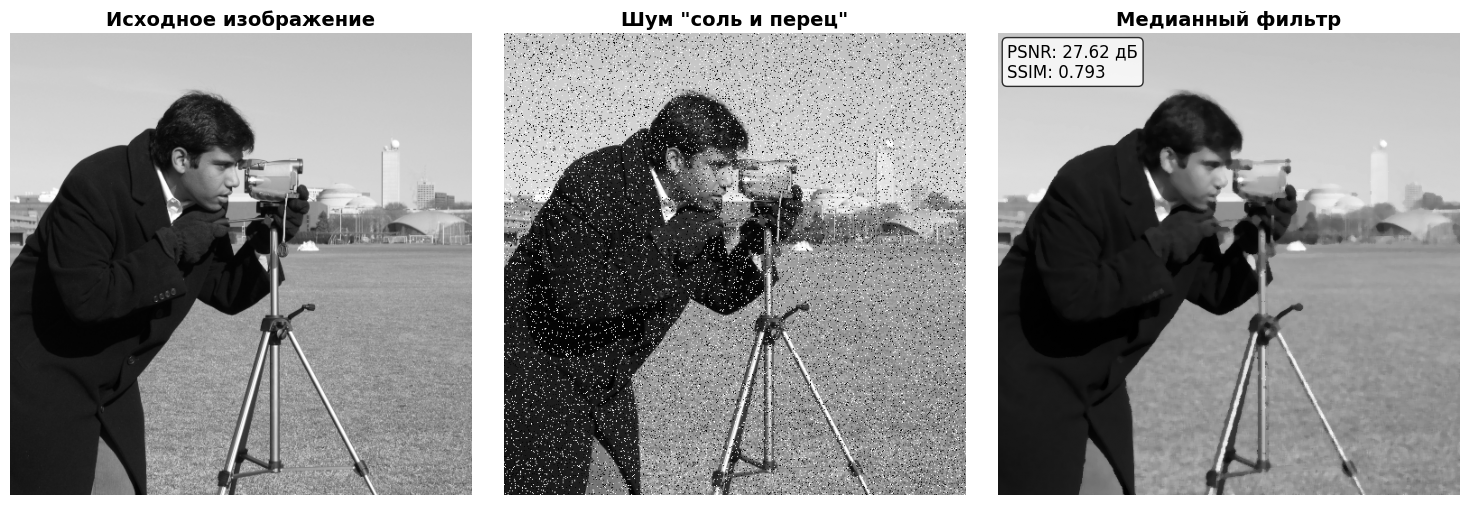

Медианный фильтр эффективно устраняет импульсный шум, сохраняя четкие границы объектов.


In [11]:
# Загрузка тестового изображения
image = img_as_float(data.camera())

# Добавление импульсного шума
noisy_image = add_noise(image, 'salt_pepper', amount=0.1)

# Применение медианного фильтра
median_filtered = cv2.medianBlur((noisy_image * 255).astype(np.uint8), 5) / 255.0

# Отображение результатов
display_results(image, noisy_image, median_filtered,
               ['Исходное изображение', 'Шум "соль и перец"', 'Медианный фильтр'])

print("Медианный фильтр эффективно устраняет импульсный шум, сохраняя четкие границы объектов.")

## 2. Гауссов фильтр
Гауссов фильтр применяет взвешенное усреднение с весами по гауссовому распределению.

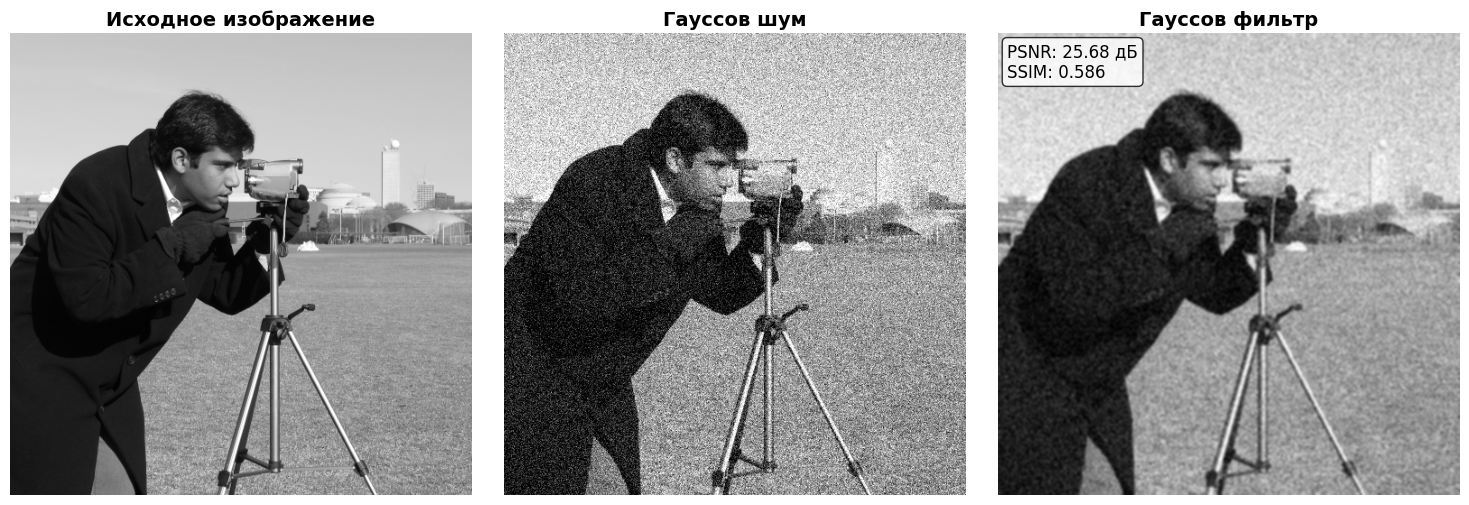

Гауссов фильтр эффективен против гауссова шума, но может размывать края.


In [19]:
# Добавление гауссова шума
noisy_gaussian = add_noise(image, 'gaussian', var=0.02)

# Применение гауссова фильтра
gaussian_filtered = cv2.GaussianBlur(noisy_gaussian, (5, 5), 1.5)

# Отображение результатов
display_results(image, noisy_gaussian, gaussian_filtered,
               ['Исходное изображение', 'Гауссов шум', 'Гауссов фильтр'])

print("Гауссов фильтр эффективен против гауссова шума, но может размывать края.")

## 3. Билатеральный фильтр
Билатеральный фильтр сохраняет края, учитывая как пространственную близость, так и радиометрическое сходство пикселей.

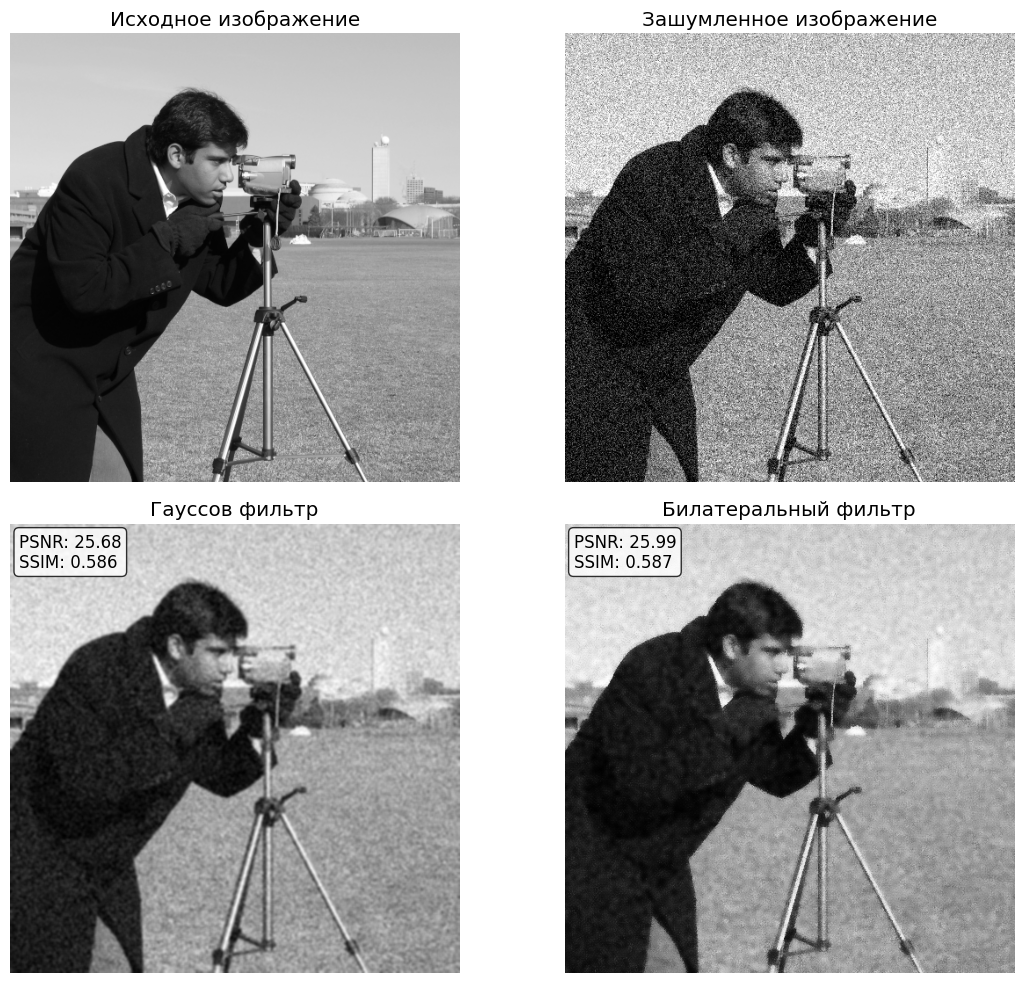

Билатеральный фильтр лучше сохраняет края по сравнению с гауссовым фильтром
Улучшение PSNR: 0.31 дБ


In [20]:
# Применение билатерального фильтра
bilateral_filtered = cv2.bilateralFilter((noisy_gaussian * 255).astype(np.uint8),
                                       d=9, sigmaColor=75, sigmaSpace=75) / 255.0

# Сравнение с гауссовым фильтром
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].imshow(image, cmap='gray')
axes[0,0].set_title('Исходное изображение')
axes[0,0].axis('off')

axes[0,1].imshow(noisy_gaussian, cmap='gray')
axes[0,1].set_title('Зашумленное изображение')
axes[0,1].axis('off')

axes[1,0].imshow(gaussian_filtered, cmap='gray')
axes[1,0].set_title('Гауссов фильтр')
axes[1,0].axis('off')
psnr_g, ssim_g = calculate_metrics(image, gaussian_filtered)
axes[1,0].text(0.02, 0.98, f'PSNR: {psnr_g:.2f}\nSSIM: {ssim_g:.3f}',
               transform=axes[1,0].transAxes, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[1,1].imshow(bilateral_filtered, cmap='gray')
axes[1,1].set_title('Билатеральный фильтр')
axes[1,1].axis('off')
psnr_b, ssim_b = calculate_metrics(image, bilateral_filtered)
axes[1,1].text(0.02, 0.98, f'PSNR: {psnr_b:.2f}\nSSIM: {ssim_b:.3f}',
               transform=axes[1,1].transAxes, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Билатеральный фильтр лучше сохраняет края по сравнению с гауссовым фильтром")
print(f"Улучшение PSNR: {psnr_b - psnr_g:.2f} дБ")

## 4. Non-Local Means
Алгоритм Non-Local Means заменяет значение пикселя средним значением всех похожих пикселей изображения.

Оценка стандартного отклонения шума: 0.1294


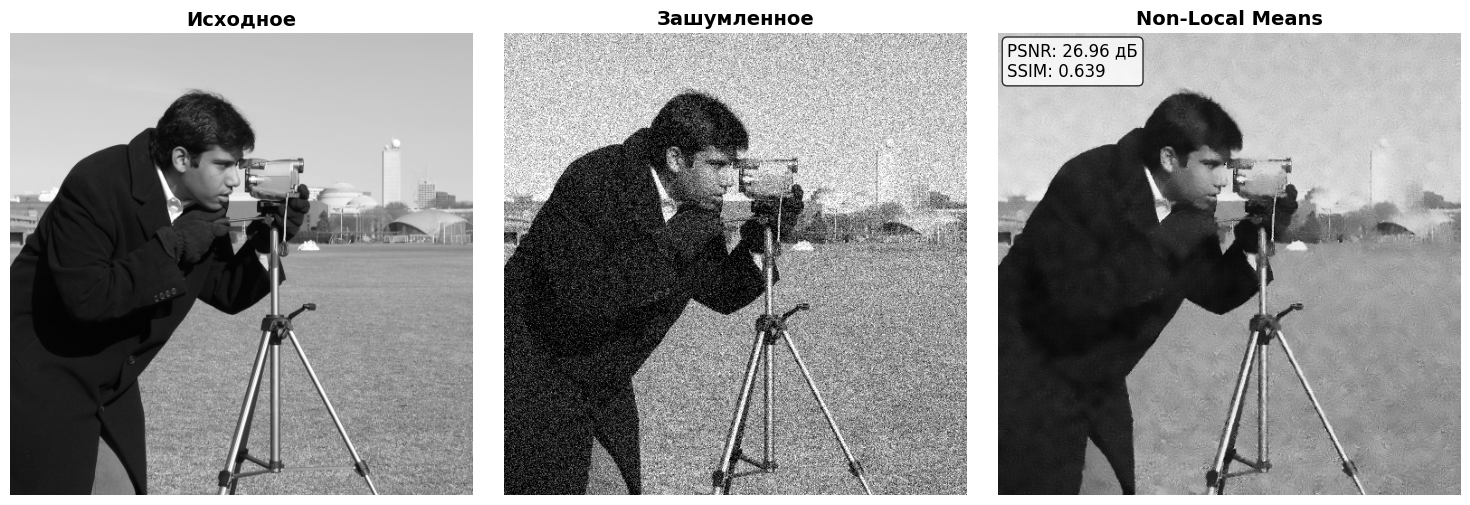

Non-Local Means эффективно восстанавливает текстуры и мелкие детали.


In [21]:
# Применение Non-Local Means фильтра
sigma_est = estimate_sigma(noisy_gaussian, channel_axis=None)
print(f'Оценка стандартного отклонения шума: {sigma_est:.4f}')

# NLM с оптимальными параметрами
nlm_result = denoise_nl_means(noisy_gaussian, h=0.8 * sigma_est, fast_mode=True,
                           patch_size=5, patch_distance=6)

# Отображение результатов
display_results(image, noisy_gaussian, nlm_result,
               ['Исходное', 'Зашумленное', 'Non-Local Means'])

print("Non-Local Means эффективно восстанавливает текстуры и мелкие детали.")

## 5. Вейвлет-преобразование для шумоподавления
Вейвлет-шумоподавление работает в частотной области, применяя пороговую обработку к коэффициентам.

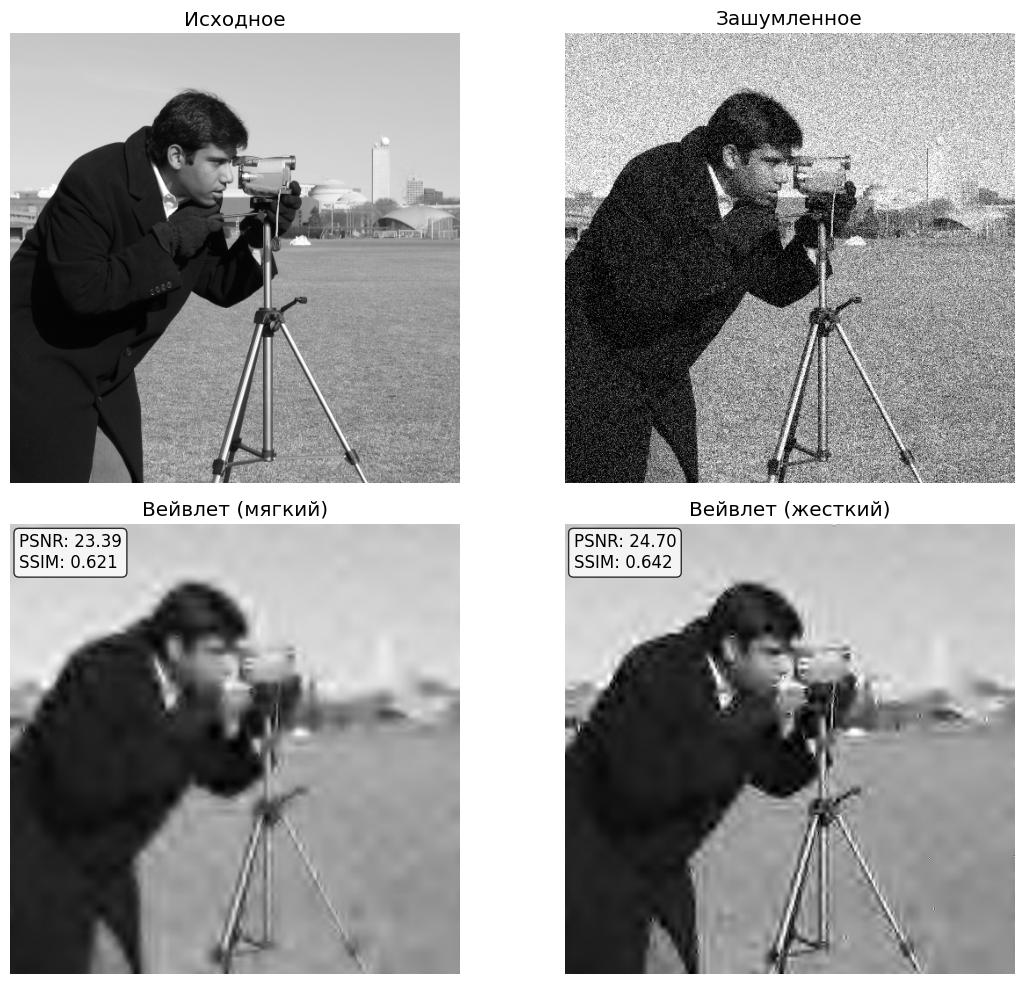

Мягкая пороговая обработка дает более гладкие результаты.
Жесткая пороговая обработка лучше сохраняет резкие переходы.


In [22]:
def wavelet_denoise(image, wavelet='db4', sigma=None, mode='soft'):
    """
    Шумоподавление с использованием вейвлет-преобразования
    """
    # Вейвлет-декомпозиция
    coeffs = pywt.wavedec2(image, wavelet, level=4)

    # Оценка шума по детализирующим коэффициентам
    if sigma is None:
        sigma = np.median(np.abs(coeffs[-1])) / 0.6745

    # Вычисление порога
    threshold = sigma * np.sqrt(2 * np.log(image.size))

    # Пороговая обработка коэффициентов
    coeffs_thresh = list(coeffs)
    coeffs_thresh[0] = coeffs[0]  # Сохраняем аппроксимирующие коэффициенты

    for i in range(1, len(coeffs)):
        coeffs_thresh[i] = tuple([pywt.threshold(detail_coeffs, threshold, mode)
                                 for detail_coeffs in coeffs[i]])

    # Восстановление изображения
    image_denoised = pywt.waverec2(coeffs_thresh, wavelet)

    return np.clip(image_denoised, 0, 1)

# Применение вейвлет-шумоподавления
wavelet_soft = wavelet_denoise(noisy_gaussian, mode='soft')
wavelet_hard = wavelet_denoise(noisy_gaussian, mode='hard')

# Сравнение мягкой и жесткой пороговой обработки
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

images = [image, noisy_gaussian, wavelet_soft, wavelet_hard]
titles = ['Исходное', 'Зашумленное', 'Вейвлет (мягкий)', 'Вейвлет (жесткий)']

for i, (img, title) in enumerate(zip(images, titles)):
    row, col = i // 2, i % 2
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(title)
    axes[row, col].axis('off')

    if i > 1:  # Добавляем метрики для обработанных изображений
        psnr, ssim = calculate_metrics(image, img)
        axes[row, col].text(0.02, 0.98, f'PSNR: {psnr:.2f}\nSSIM: {ssim:.3f}',
                           transform=axes[row, col].transAxes, verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("Мягкая пороговая обработка дает более гладкие результаты.")
print("Жесткая пороговая обработка лучше сохраняет резкие переходы.")

## 6. Total Variation (TV) Denoising
Метод Total Variation минимизирует общую вариацию изображения, эффективно удаляя шум при сохранении границ.

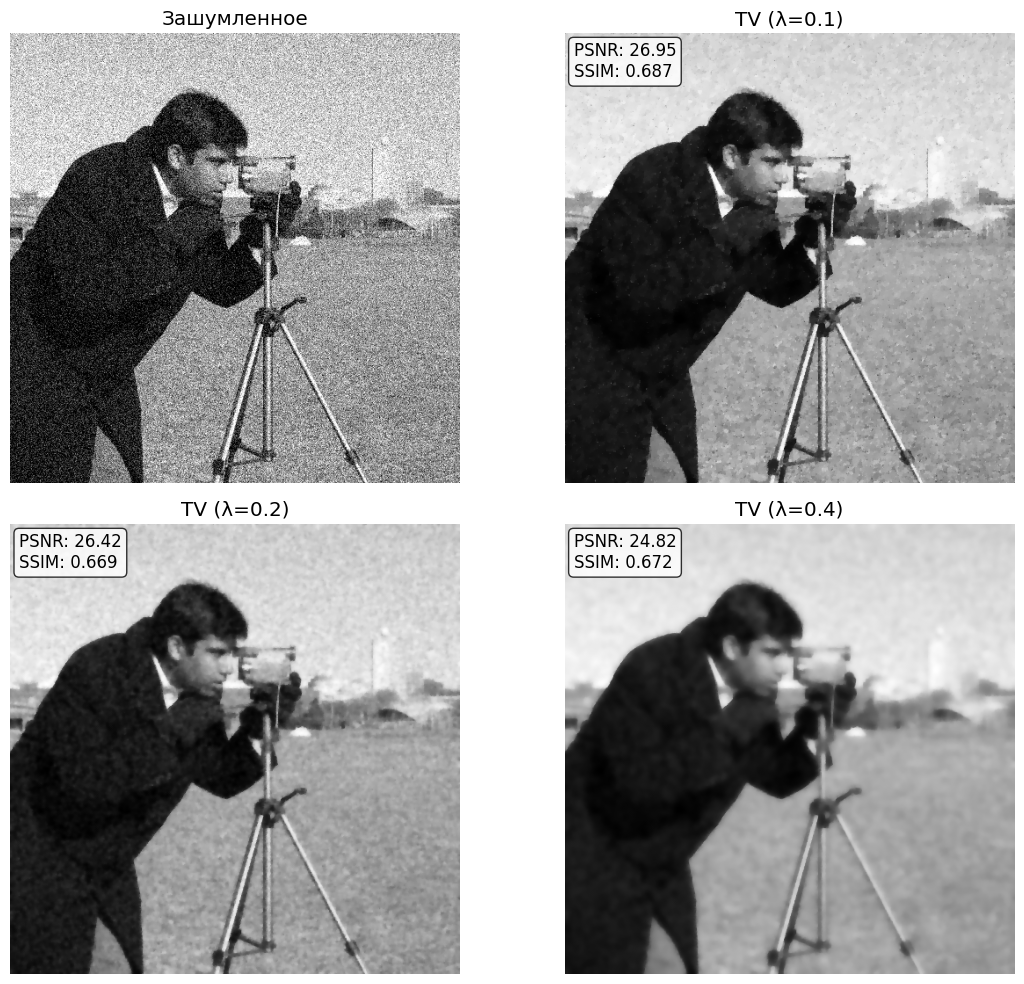

Параметр регуляризации λ контролирует баланс между шумоподавлением и сохранением деталей.
Большие значения λ приводят к более сильному сглаживанию.


In [23]:
# Применение TV denoising с различными параметрами регуляризации
tv_light = denoise_tv_chambolle(noisy_gaussian, weight=0.1)
tv_moderate = denoise_tv_chambolle(noisy_gaussian, weight=0.2)
tv_strong = denoise_tv_chambolle(noisy_gaussian, weight=0.4)

# Отображение результатов
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

images = [noisy_gaussian, tv_light, tv_moderate, tv_strong]
titles = ['Зашумленное', 'TV (λ=0.1)', 'TV (λ=0.2)', 'TV (λ=0.4)']

for i, (img, title) in enumerate(zip(images, titles)):
    row, col = i // 2, i % 2
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(title)
    axes[row, col].axis('off')

    if i > 0:  # Добавляем метрики для обработанных изображений
        psnr, ssim = calculate_metrics(image, img)
        axes[row, col].text(0.02, 0.98, f'PSNR: {psnr:.2f}\nSSIM: {ssim:.3f}',
                           transform=axes[row, col].transAxes, verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("Параметр регуляризации λ контролирует баланс между шумоподавлением и сохранением деталей.")
print("Большие значения λ приводят к более сильному сглаживанию.")

## 7. Сравнительный анализ методов
Проведем комплексное сравнение всех изученных методов.

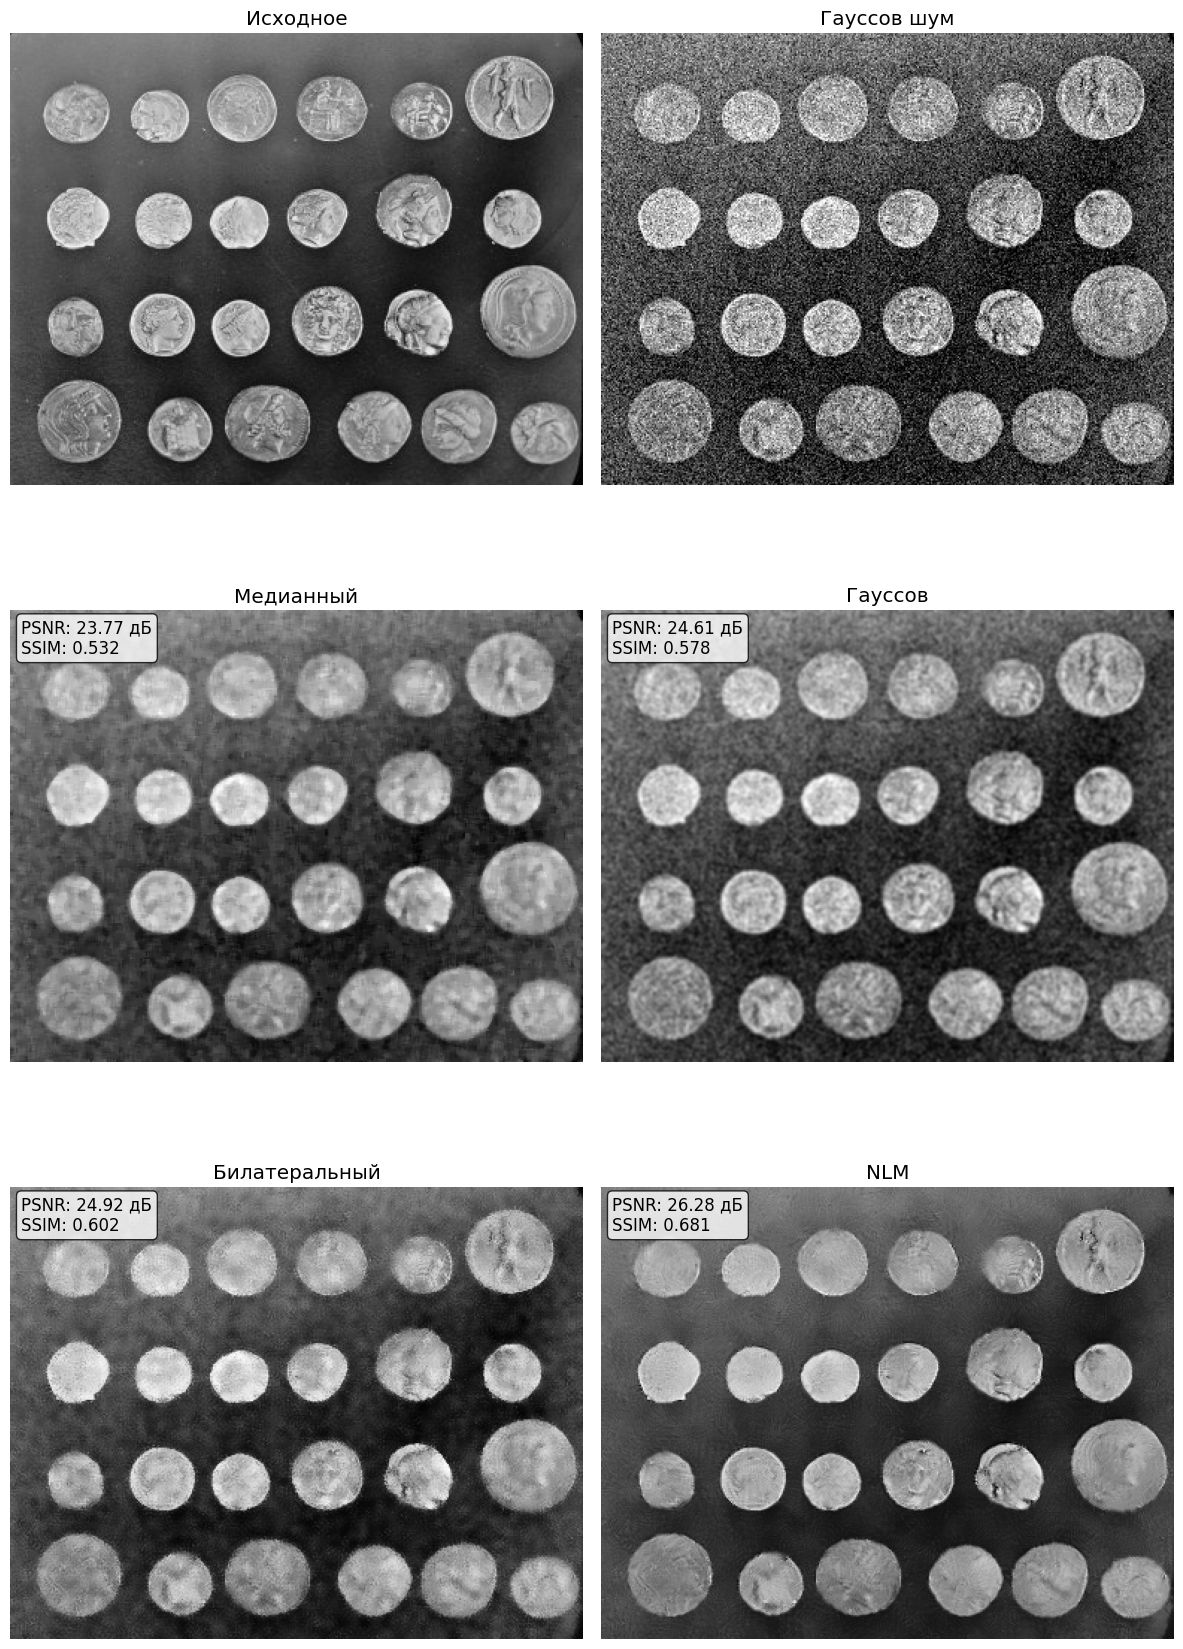

ValueError: Input images must have the same dimensions.

In [24]:
# 7. Сравнительный анализ методов
test_image = img_as_float(data.coins())
gaussian_noise = add_noise(test_image, 'gaussian', var=0.02)

methods_results = {
    'Медианный': cv2.medianBlur((gaussian_noise*255).astype(np.uint8), 5)/255.0,
    'Гауссов': cv2.GaussianBlur(gaussian_noise, (5,5), 1.0),
    'Билатеральный': cv2.bilateralFilter((gaussian_noise*255).astype(np.uint8), 9,75,75)/255.0,
    'NLM': denoise_nl_means(gaussian_noise, h=0.8*estimate_sigma(gaussian_noise, channel_axis=None),
                           fast_mode=True, patch_size=5, patch_distance=6),
    'Вейвлет': wavelet_denoise(gaussian_noise, mode='soft'),
    'TV': denoise_tv_chambolle(gaussian_noise, weight=0.15)
}

# Графическое сравнение
fig, axes = plt.subplots(3, 2, figsize=(12, 18))
axes = axes.ravel()
titles = ['Исходное', 'Гауссов шум'] + list(methods_results.keys())
images = [test_image, gaussian_noise] + list(methods_results.values())

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
    if title not in ['Исходное', 'Гауссов шум']:
        psnr, ssim = calculate_metrics(test_image, img)
        ax.text(0.02, 0.98, f'PSNR: {psnr:.2f} дБ\nSSIM: {ssim:.3f}',
                transform=ax.transAxes, va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

# Табличный вывод метрик
metrics_table = []
for name, denoised in methods_results.items():
    psnr, ssim = calculate_metrics(test_image, denoised)
    metrics_table.append((name, psnr, ssim))

print(f"{'Метод':<12} {'PSNR(дБ)':>10} {'SSIM':>8}")
print('-'*34)
for name, psnr, ssim in sorted(metrics_table, key=lambda x: x[1], reverse=True):
    print(f"{name:<12} {psnr:>10.2f} {ssim:>8.3f}")

## 8. Работа с цветными изображениями
Демонстрация FastNLMeans для цветных изображений.

ValueError: win_size exceeds image extent. Either ensure that your images are at least 7x7; or pass win_size explicitly in the function call, with an odd value less than or equal to the smaller side of your images. If your images are multichannel (with color channels), set channel_axis to the axis number corresponding to the channels.

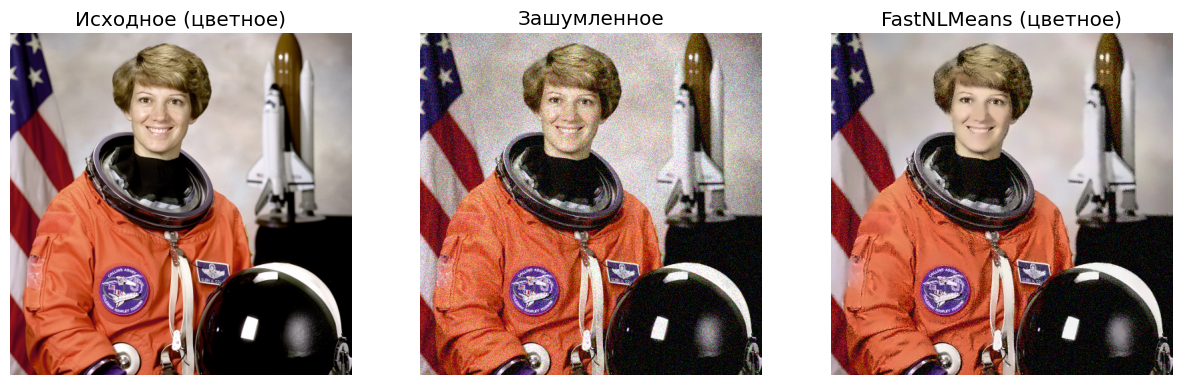

In [26]:
# Загрузка цветного изображения
color_image = img_as_float(data.astronaut())
color_noisy = add_noise(color_image, 'gaussian', var=0.01)

# Применение FastNLMeans для цветных изображений
color_denoised = cv2.fastNlMeansDenoisingColored(
    (color_noisy * 255).astype(np.uint8),
    None, 10, 10, 7, 21
) / 255.0

# Отображение результатов
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(color_image)
axes[0].set_title('Исходное (цветное)')
axes[0].axis('off')

axes[1].imshow(color_noisy)
axes[1].set_title('Зашумленное')
axes[1].axis('off')

axes[2].imshow(color_denoised)
axes[2].set_title('FastNLMeans (цветное)')
axes[2].axis('off')

# Добавление метрик
psnr_color, ssim_color = calculate_metrics(color_image, color_denoised)
axes[2].text(0.02, 0.98, f'PSNR: {psnr_color:.2f}\nSSIM: {ssim_color:.3f}',
               transform=axes[2].transAxes, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("FastNLMeans от OpenCV обеспечивает быструю и эффективную реализацию для цветных изображений.")

## 9. Задания для самостоятельной работы

### Задание 1: Анализ параметров билатерального фильтра
1. Загрузите собственное изображение или используйте из `skimage.data`
2. Добавьте гауссов шум с σ = 0.05
3. Примените билатеральный фильтр с разными параметрами:
   - d = [5, 9, 15]
   - σ_color = [50, 75, 100]
   - σ_space = [50, 75, 100]
4. Постройте графики зависимости PSNR и SSIM от параметров
5. Определите оптимальные параметры

### Задание 2: Сравнение методов на разных типах шума
1. Создайте синтетическое изображение с геометрическими фигурами
2. Добавьте смешанный шум (гауссов + импульсный)
3. Примените все изученные методы
4. Создайте таблицу сравнения по метрикам
5. Проанализируйте визуальное качество результатов

### Задание 3: Разработка гибридного метода
1. Разработайте собственный гибридный алгоритм
2. Комбинируйте 2-3 различных метода
3. Реализуйте автоматический выбор параметров
4. Протестируйте на различных типах изображений
5. Сравните с стандартными методами

In [ ]:
# Задание 1

# Ваш код здесь...

In [ ]:
# Задание 2

# Ваш код здесь...

In [ ]:
# Задание 3

# Ваш код здесь...